# AI-Powered Student Performance Prediction & Early Warning System

## Domain
Education

## Objective
To predict student academic performance using machine learning and identify students who are at risk of failing. The system also provides personalized study recommendations.

## Features
1. Student performance prediction
2. Early warning system (risk detection)
3. Personalized study recommendations

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

### Load Dataset

In [2]:
df = pd.read_csv("student_performance_600.csv")

df.head()

,StudyTime,Absences,PreviousGrade,AssignmentsCompleted,Participation,FinalGrade
0,4,10,62,3,5,47.91
1,5,11,86,4,4,57.03
2,3,4,65,10,2,68.45
3,5,3,85,7,2,82.69
4,5,2,82,10,4,82.51


### Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StudyTime             600 non-null    int64  
 1   Absences              600 non-null    int64  
 2   PreviousGrade         600 non-null    int64  
 3   AssignmentsCompleted  600 non-null    int64  
 4   Participation         600 non-null    int64  
 5   FinalGrade            600 non-null    float64
dtypes: float64(1), int64(5)
memory usage: 28.3 KB


In [4]:
df.describe()

,StudyTime,Absences,PreviousGrade,AssignmentsCompleted,Participation,FinalGrade
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,3.018333,6.906667,67.898333,6.486667,3.033333,57.700433
std,1.436931,4.431782,15.823463,2.252764,1.439563,14.448841
min,1.000000,0.000000,40.000000,3.000000,1.000000,20.260000
25%,2.000000,3.000000,55.000000,5.000000,2.000000,47.265000
50%,3.000000,7.000000,68.000000,6.000000,3.000000,57.900000
75%,4.000000,11.000000,82.000000,8.000000,4.000000,68.230000
max,5.000000,14.000000,94.000000,10.000000,5.000000,97.460000


### Check Missing Values

In [5]:
df.isnull().sum()

StudyTime               0
Absences                0
PreviousGrade           0
AssignmentsCompleted    0
Participation           0
FinalGrade              0
dtype: int64

### Data Visualization

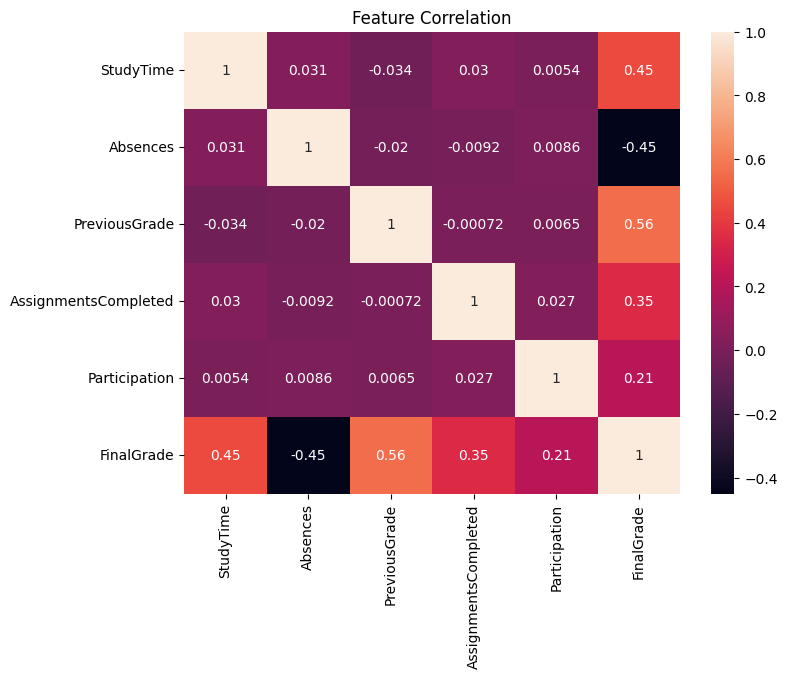

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)

plt.title("Feature Correlation")
plt.show()

#### Study Time vs Final Grade

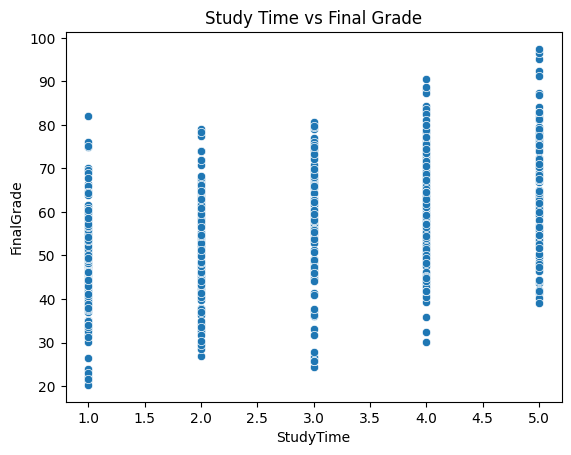

In [7]:
sns.scatterplot(x="StudyTime", y="FinalGrade", data=df)

plt.title("Study Time vs Final Grade")
plt.show()

### Feature Selection

In [8]:
X = df[['StudyTime',
        'Absences',
        'PreviousGrade',
        'AssignmentsCompleted',
        'Participation']]

y = df['FinalGrade']

### Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Train Machine Learning Model

In [10]:
model = RandomForestRegressor()

model.fit(X_train, y_train)

RandomForestRegressor()

### Model Predictions

In [11]:
predictions = model.predict(X_test)

predictions[:10]

array([38.552 , 75.5087, 62.5344, 77.9229, 58.8425, 46.6839, 61.3319,
       62.0836, 88.1631, 74.4626])

### Model Evaluation

In [12]:
mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 43.4390486803334


In [18]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RMSE:", rmse)

RMSE: 6.590830651771702


### Early Warning System (Risk Classification)

In [13]:
def classify(score):

    if score < 50:
        return "At Risk"
    
    elif score < 75:
        return "Average"
    
    else:
        return "High Performer"

#### Apply classification:

In [14]:
df["PerformanceCategory"] = df["FinalGrade"].apply(classify)

df.head()

,StudyTime,Absences,PreviousGrade,AssignmentsCompleted,Participation,FinalGrade,PerformanceCategory
0,4,10,62,3,5,47.91,At Risk
1,5,11,86,4,4,57.03,Average
2,3,4,65,10,2,68.45,Average
3,5,3,85,7,2,82.69,High Performer
4,5,2,82,10,4,82.51,High Performer


### Recommendation System

In [15]:
def recommend(study, absences, participation):

    advice = []

    if study < 2:
        advice.append("Increase study time")

    if absences > 7:
        advice.append("Improve attendance")

    if participation < 3:
        advice.append("Participate more in class")

    if not advice:
        advice.append("Maintain current study pattern")

    return advice

### Test the System

In [21]:
study = 1
absences = 8
previous = 80
assignments = 8
participation = 2

student = [[study, absences, previous, assignments, participation]]

predicted_grade = model.predict(student)[0]

print("Predicted Final Grade:", predicted_grade)

category = classify(predicted_grade)

print("Performance Category:", category)

print("Recommendations:")
print(recommend(study, absences, participation))

Predicted Final Grade: 57.24589999999999
Performance Category: Average
Recommendations:
['Increase study time', 'Improve attendance', 'Participate more in class']


C:\Users\abhij\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


### Feature Importance

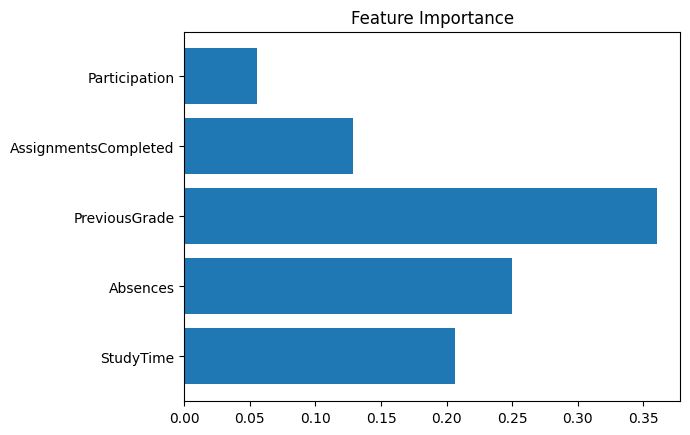

In [22]:
importance = model.feature_importances_

features = X.columns

plt.barh(features, importance)

plt.title("Feature Importance")
plt.show()

## Conclusion

This project demonstrates how artificial intelligence can help improve the education system by predicting student performance and detecting students at risk of failure.

The AI system analyzes factors such as study time, attendance, participation, and previous grades to estimate final performance.

The early warning system allows educators to intervene early and provide targeted support to struggling students.

In [24]:
import pickle

pickle.dump(model, open("student_model.pkl", "wb"))